df_plot rows = 258 | range: 2024-12-16 ~ 2025-12-26
df_sim rows = 6 | range: 2025-12-18 ~ 2025-12-26
anchor_dt: 2025-12-18 anchor_price: 51.43


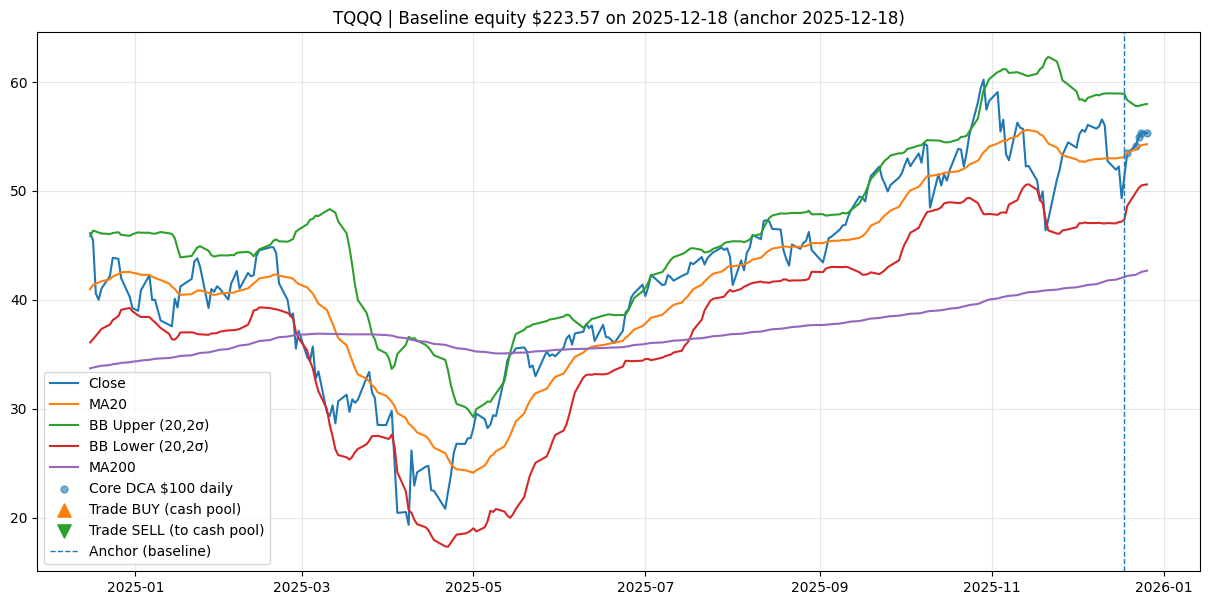


=== Anchor (your real baseline) ===
Requested START_DATE: 2025-12-18
Anchor trading date used: 2025-12-18
Anchor Close: 51.43
Initial Equity: 223.57
Initial CoreShares (equity/anchor_close): 4.347118

=== Latest ===
Date: 2025-12-26
Close: 55.31 Z: 0.55
Signals => ADD_BUY: False SELL_1: False SELL_2: False

=== Portfolio Snapshot ===
CoreShares (DCA, never sell): 4.987803
TradeShares (trade layer): 0.0
TradeCash (from trade sells): $ 0.0
TotalValue (Core + Trade + Cash): $ 275.88

Action: No trade-layer action now (only daily DCA runs).


In [1]:
#1. 매일 사는 종목 (TQQQ) 매수/매도 포지션 코드

import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt
%matplotlib inline
# =========================
# 설정
# =========================
TICKER = "TQQQ"

# 지표
BB_WINDOW = 20
BB_STD = 2.0
MA200_W = 200

# 조건 (Z-score 기준)
ADD_BUY_Z = -1.5     # (MA200 위) Z <= -1.5면 트레이딩 매수(현금풀 사용)
SELL_Z1   =  1.5     # (MA200 위) Z >= +1.5면 트레이딩 일부매도
SELL_Z2   =  2.0     # (MA200 위) Z >= +2.0면 더 강한 일부매도

# 디폴트 코어 DCA
DCA_DOLLARS_PER_DAY = 7.0

# 트레이딩 매매 비율(수량 기준) - 트레이딩 레이어 보유분에서만 매도
SELL1_FRACTION = 0.20
SELL2_FRACTION = 0.40

# 트레이딩 매수 집행 규칙(현금풀에서만)
TRADE_BUY_USE_FRACTION = 0.50  # 신호 발생 시 현금풀의 50% 사용
MIN_TRADE_BUY_DOLLARS = 200.0  # 현금풀이 너무 작으면 패스

# 데이터
PERIOD = "5y"
INTERVAL = "1d"

# 실제 계좌 기준점 (12/19 장 시작 전이면 최신 거래일은 12/18로 잡히는 게 정상)
START_DATE = "2025-12-18"
INITIAL_EQUITY = 223.57       # 2025-12-18 기준 평가금액
INITIAL_TRADE_CASH = 0.0
INITIAL_TRADE_SHARES = 0.0

# 그래프 표시용 룩백(앵커일 이전 N 거래일을 함께 보여줌)
LOOKBACK_BARS = 252  # 1년 거래일 정도 (원하면 180 등으로 조정)

# =========================
# 데이터 로드
# =========================
df = yf.download(
    TICKER,
    period=PERIOD,
    interval=INTERVAL,
    auto_adjust=True,
    group_by="column",
    progress=False,
).dropna()

# 멀티인덱스 컬럼 평탄화(환경별로 필요)
if isinstance(df.columns, pd.MultiIndex):
    df.columns = df.columns.get_level_values(0)

if "Close" not in df.columns:
    raise ValueError(f"'Close' 컬럼이 없습니다. columns={df.columns}")

# =========================
# 지표 계산
# =========================
close = df["Close"].astype(float)

df["MA20"]  = close.rolling(BB_WINDOW).mean()
df["STD20"] = close.rolling(BB_WINDOW).std(ddof=0).replace(0, np.nan)
df["Upper"] = df["MA20"] + BB_STD * df["STD20"]
df["Lower"] = df["MA20"] - BB_STD * df["STD20"]
df["MA200"] = close.rolling(MA200_W).mean()
df["Z"]     = (close - df["MA20"]) / df["STD20"]

df = df.dropna().copy()

if len(df) < MA200_W + BB_WINDOW + 5:
    raise ValueError("데이터가 부족합니다. PERIOD를 더 늘려보세요(예: 10y).")

# =========================
# START_DATE 기준 앵커 거래일 잡기 (START_DATE가 휴장일일 수 있음)
# =========================
start_ts = pd.Timestamp(START_DATE)
df_before_or_on = df[df.index <= start_ts]
if df_before_or_on.empty:
    raise ValueError("START_DATE 이전/당일 데이터가 없습니다. START_DATE/PERIOD를 확인하세요.")

anchor_dt = df_before_or_on.index[-1]  # START_DATE 이전/당일의 마지막 거래일
anchor_price = float(df.loc[anchor_dt, "Close"])

# 시뮬 구간: 앵커일부터
df_sim = df[df.index >= anchor_dt].copy()
if df_sim.empty:
    raise ValueError("df_sim이 비었습니다. date filter를 확인하세요.")

# =========================
# 초기 포지션 주입 (네 실제 계좌를 앵커일 종가로 주식 수 역산)
# =========================
core_shares = INITIAL_EQUITY / anchor_price
trade_shares = float(INITIAL_TRADE_SHARES)
trade_cash = float(INITIAL_TRADE_CASH)

# 신호 계산(시뮬 구간)
df_sim["ADD_BUY"] = (df_sim["Close"] > df_sim["MA200"]) & (df_sim["Z"] <= ADD_BUY_Z)
df_sim["SELL_1"]  = (df_sim["Close"] > df_sim["MA200"]) & (df_sim["Z"] >= SELL_Z1)
df_sim["SELL_2"]  = (df_sim["Close"] > df_sim["MA200"]) & (df_sim["Z"] >= SELL_Z2)

# =========================
# 시뮬레이션 (앵커일은 초기화한 날이라 DCA 스킵, 다음 거래일부터 DCA)
# =========================
records = []

for i, (dt, row) in enumerate(df_sim.iterrows()):
    price = float(row["Close"])

    # 코어 DCA (앵커일 제외)
    core_buy_shares = 0.0
    if i > 0:
        core_buy_shares = DCA_DOLLARS_PER_DAY / price
        core_shares += core_buy_shares

    # 트레이딩 매도 우선(SELL_2 > SELL_1)
    did_trade_sell_shares = 0.0
    did_trade_sell_dollars = 0.0

    if bool(row["SELL_2"]) and trade_shares > 0:
        sell_shares = min(trade_shares, trade_shares * SELL2_FRACTION)
        trade_shares -= sell_shares
        proceeds = sell_shares * price
        trade_cash += proceeds
        did_trade_sell_shares = sell_shares
        did_trade_sell_dollars = proceeds

    elif bool(row["SELL_1"]) and trade_shares > 0:
        sell_shares = min(trade_shares, trade_shares * SELL1_FRACTION)
        trade_shares -= sell_shares
        proceeds = sell_shares * price
        trade_cash += proceeds
        did_trade_sell_shares = sell_shares
        did_trade_sell_dollars = proceeds

    # 트레이딩 매수(현금풀 일부 사용)
    did_trade_buy_shares = 0.0
    did_trade_buy_dollars = 0.0

    if bool(row["ADD_BUY"]) and trade_cash >= MIN_TRADE_BUY_DOLLARS:
        spend = trade_cash * TRADE_BUY_USE_FRACTION
        if spend >= MIN_TRADE_BUY_DOLLARS:
            buy_shares = spend / price
            trade_shares += buy_shares
            trade_cash -= spend
            did_trade_buy_shares = buy_shares
            did_trade_buy_dollars = spend

    # 평가
    core_value = core_shares * price
    trade_value = trade_shares * price
    total_value = core_value + trade_value + trade_cash

    records.append({
        "Date": dt,
        "Close": price,
        "Z": float(row["Z"]),
        "CoreShares": core_shares,
        "TradeShares": trade_shares,
        "TradeCash": trade_cash,
        "CoreValue": core_value,
        "TradeValue": trade_value,
        "TotalValue": total_value,
        "CoreBuyShares": core_buy_shares,
        "TradeBuyShares": did_trade_buy_shares,
        "TradeBuyDollars": did_trade_buy_dollars,
        "TradeSellShares": did_trade_sell_shares,
        "TradeSellDollars": did_trade_sell_dollars,
        "Signal_ADD_BUY": bool(row["ADD_BUY"]),
        "Signal_SELL_1": bool(row["SELL_1"]),
        "Signal_SELL_2": bool(row["SELL_2"]),
    })

bt = pd.DataFrame(records).set_index("Date")

# =========================
# 차트 표시용 구간 확장(앵커일 이전 LOOKBACK_BARS 만큼 보여주기)
# =========================
anchor_pos = df.index.get_loc(anchor_dt)
start_pos = max(0, anchor_pos - LOOKBACK_BARS)
end_pos = df.index.get_loc(df_sim.index[-1]) + 1
df_plot = df.iloc[start_pos:end_pos].copy()

print("df_plot rows =", len(df_plot),
      "| range:", df_plot.index.min().date(), "~", df_plot.index.max().date())
print("df_sim rows =", len(df_sim),
      "| range:", df_sim.index.min().date(), "~", df_sim.index.max().date())
print("anchor_dt:", anchor_dt.date(), "anchor_price:", round(anchor_price, 2))

# =========================
# 차트 표시 (가격 + 밴드 + 신호)
# =========================
fig, ax = plt.subplots(figsize=(15, 7))

ax.plot(df_plot.index, df_plot["Close"], label="Close")
ax.plot(df_plot.index, df_plot["MA20"], label="MA20")
ax.plot(df_plot.index, df_plot["Upper"], label="BB Upper (20,2σ)")
ax.plot(df_plot.index, df_plot["Lower"], label="BB Lower (20,2σ)")
ax.plot(df_plot.index, df_plot["MA200"], label="MA200")

# DCA 마커 (시뮬 구간에서 실제로 실행된 날만)
dca_pts = bt[bt["CoreBuyShares"] > 0]
ax.scatter(dca_pts.index, dca_pts["Close"], marker="o", s=25, alpha=0.6, label="Core DCA $100 daily")

# 실제 체결된 트레이딩 매수/매도 표시
trade_buys = bt[bt["TradeBuyDollars"] > 0]
trade_sells = bt[bt["TradeSellDollars"] > 0]
ax.scatter(trade_buys.index, trade_buys["Close"], marker="^", s=90, label="Trade BUY (cash pool)")
ax.scatter(trade_sells.index, trade_sells["Close"], marker="v", s=90, label="Trade SELL (to cash pool)")

# 앵커일 표시
ax.axvline(anchor_dt, linestyle="--", linewidth=1, label="Anchor (baseline)")

ax.set_title(f"{TICKER} | Baseline equity ${INITIAL_EQUITY} on {START_DATE} (anchor {anchor_dt.date()})")
ax.grid(True, alpha=0.3)
ax.legend()
plt.show()

# =========================
# 최신 상태 / 오늘 액션 가이드
# =========================
last_dt = df_sim.index[-1]
last_sig = df_sim.iloc[-1]
last_bt = bt.iloc[-1]

print("\n=== Anchor (your real baseline) ===")
print("Requested START_DATE:", START_DATE)
print("Anchor trading date used:", anchor_dt.date())
print("Anchor Close:", round(anchor_price, 2))
print("Initial Equity:", INITIAL_EQUITY)
print("Initial CoreShares (equity/anchor_close):", round(INITIAL_EQUITY / anchor_price, 6))

print("\n=== Latest ===")
print("Date:", last_dt.date())
print("Close:", round(float(last_sig["Close"]), 2), "Z:", round(float(last_sig["Z"]), 2))
print("Signals => ADD_BUY:", bool(last_sig["Signal_ADD_BUY"]) if "Signal_ADD_BUY" in last_sig else bool(last_sig["ADD_BUY"]),
      "SELL_1:", bool(last_sig["SELL_1"]), "SELL_2:", bool(last_sig["SELL_2"]))

print("\n=== Portfolio Snapshot ===")
print("CoreShares (DCA, never sell):", round(float(last_bt["CoreShares"]), 6))
print("TradeShares (trade layer):", round(float(last_bt["TradeShares"]), 6))
print("TradeCash (from trade sells): $", round(float(last_bt["TradeCash"]), 2))
print("TotalValue (Core + Trade + Cash): $", round(float(last_bt["TotalValue"]), 2))

if bool(last_sig["SELL_2"]) and last_bt["TradeShares"] > 0:
    print("\nAction: SELL strong (trade layer) - if market open and signal persists.")
elif bool(last_sig["SELL_1"]) and last_bt["TradeShares"] > 0:
    print("\nAction: SELL (trade layer) - if market open and signal persists.")
elif bool(last_sig["ADD_BUY"]) and last_bt["TradeCash"] >= MIN_TRADE_BUY_DOLLARS:
    print("\nAction: BUY (trade layer) using cash pool - if market open and signal persists.")
else:
    print("\nAction: No trade-layer action now (only daily DCA runs).")


raw last date: 2025-12-26 00:00:00
Latest QQQ trading date: 2025-12-26
VIX last date: 2025-12-26
VIX3M last date: 2025-12-26

=== Daily Decision (Quantile-based RAI) ===
Latest trading date: 2025-12-26
RAI: -0.008 | Quantile(rolling 2y): 0.819
Target weight (QQQ): 100% | Current weight: 70%
Features used: 8/8
Action: +30.0%p BUY  (~$3,000 QQQ 매수)

--- Last 20 trading days snapshot (with Action) ---
            QQQ_Close    RAI      Q  TargetW  PrevW(approx)  ExecDay  \
Date                                                                   
2025-11-13     607.62 -0.014  0.740     0.85           0.70    False   
2025-11-14     608.08 -0.017  0.675     0.85           0.70     True   
2025-11-17     602.88 -0.014  0.738     0.85           0.85    False   
2025-11-18     595.54 -0.010  0.804     1.00           0.85    False   
2025-11-19     599.10 -0.012  0.780     1.00           0.85    False   
2025-11-20     584.92 -0.007  0.849     1.00           0.85    False   
2025-11-21     589.31 

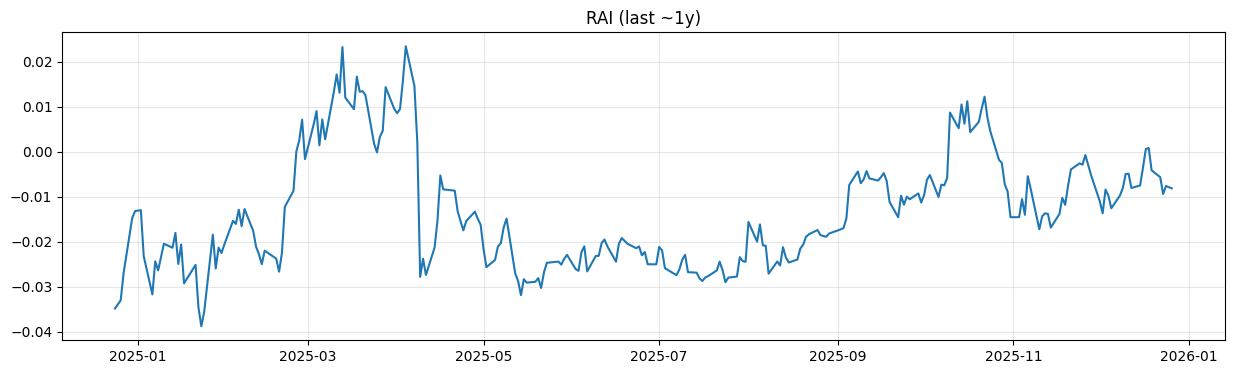

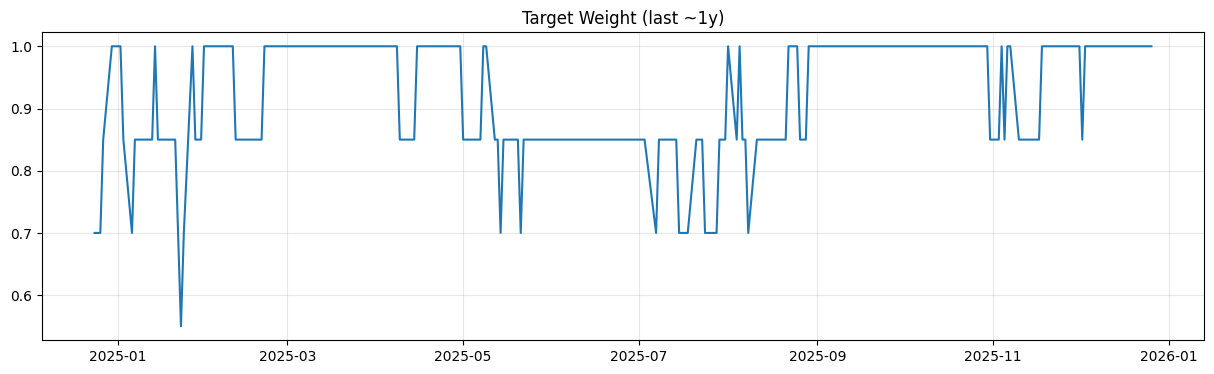

In [2]:
#2. 지수 추종 매수/매도 포지션 코드

import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt
%matplotlib inline
# ============================================================
# 0) 매일 너가 바꾸는 값 (매일 실행 시 여기만 수정)
# ============================================================
PORTFOLIO_VALUE = 10_000          # 전체 포트폴리오 평가금액(달러)
CURRENT_QQQ_WEIGHT = 0.70         # 현재 QQQ 비중(0~1)

# 리밸런싱(실행) 빈도: "D"(매일) / "W-FRI"(주1회 금요일) / "M"(월말)
REBALANCE_FREQ = "W-FRI"

# 현금 수익률 반영 옵션:
# - "zero": 현금 0% 가정(간단)
# - "SHY" : SHY(단기국채 ETF)로 현금 대체
CASH_MODE = "zero"
CASH_TICKER = "SHY"

# 분위수(Quantile) 계산: 최근 N년 롤링 분포 기준
ROLL_YEARS_FOR_QUANTILE = 2

# 데이터/지표 설정
LOOKBACK_YEARS = 10
ZS_WIN = 252

# ============================================================
# 1) 학습 결과 weight + 방향 (너가 공유한 ridge weight 그대로)
# ============================================================
W_FULL = pd.Series({
    "vix_level": 0.0087,
    "small_big": 0.0079,
    "realized_vol20": 0.0033,
    "cyc_def": 0.0023,
    "adx14": 0.0007,
    "vix_term": -0.0044,
    "credit_risk": -0.0147,
    "trend_200": -0.0162
})

# Risk-on 방향 통일(부호)
DIRECTION = {
    "vix_level": -1,
    "vix_term": -1,
    "realized_vol20": -1,
    "credit_risk": +1,
    "cyc_def": +1,
    "small_big": +1,
    "trend_200": +1,
    "adx14": +1
}

# ============================================================
# 2) 분위수 → 목표비중 (급락에도 반응하도록 "상대순위" 기반)
# ============================================================
def quantile_to_weight(q: float) -> float:
    if q <= 0.10:
        return 0.40
    elif q <= 0.25:
        return 0.55
    elif q <= 0.50:
        return 0.70
    elif q <= 0.75:
        return 0.85
    else:
        return 1.00

def clamp01(x: float) -> float:
    return float(max(0.0, min(1.0, x)))

# ============================================================
# 3) 유틸 함수들
# ============================================================
def zscore_rolling(s: pd.Series, win: int = 252) -> pd.Series:
    m = s.rolling(win).mean()
    sd = s.rolling(win).std(ddof=0)
    return (s - m) / sd

def realized_vol(ret: pd.Series, win: int = 20) -> pd.Series:
    return ret.rolling(win).std(ddof=0) * np.sqrt(252)

def adx(high: pd.Series, low: pd.Series, close: pd.Series, win: int = 14) -> pd.Series:
    up_move = high.diff()
    down_move = -low.diff()
    plus_dm = np.where((up_move > down_move) & (up_move > 0), up_move, 0.0)
    minus_dm = np.where((down_move > up_move) & (down_move > 0), down_move, 0.0)

    tr1 = high - low
    tr2 = (high - close.shift()).abs()
    tr3 = (low - close.shift()).abs()
    tr = pd.concat([tr1, tr2, tr3], axis=1).max(axis=1)

    atr = tr.rolling(win).mean()
    plus_di = 100 * pd.Series(plus_dm, index=close.index).rolling(win).mean() / atr
    minus_di = 100 * pd.Series(minus_dm, index=close.index).rolling(win).mean() / atr
    dx = (100 * (plus_di - minus_di).abs() / (plus_di + minus_di)).replace([np.inf, -np.inf], np.nan)
    return dx.rolling(win).mean()

def is_exec_day(dt: pd.Timestamp, all_days: pd.DatetimeIndex, freq: str) -> bool:
    if freq == "D":
        return True
    if freq == "W-FRI":
        return dt.weekday() == 4  # Fri
    if freq == "M":
        month_days = all_days[all_days.to_period("M") == dt.to_period("M")]
        return dt == month_days.max()
    raise ValueError("REBALANCE_FREQ must be 'D', 'W-FRI', or 'M'")

# ============================================================
# 4) 데이터 로드 (yfinance)
# ============================================================
base_tickers = ["SPY","QQQ","IWM","HYG","LQD","XLY","XLP","^VIX","^VIX3M"]
tickers = base_tickers.copy()
if CASH_MODE == "SHY":
    tickers = list(dict.fromkeys(tickers + [CASH_TICKER]))

START = (pd.Timestamp.today() - pd.DateOffset(years=LOOKBACK_YEARS)).strftime("%Y-%m-%d")
raw = yf.download(tickers, start=START, auto_adjust=True, group_by="column", progress=False)

def get_field(df, ticker, field="Close"):
    if isinstance(df.columns, pd.MultiIndex):
        return df[field][ticker].copy()
    return df[field].copy()

spy_c = get_field(raw, "SPY", "Close")
spy_h = get_field(raw, "SPY", "High")
spy_l = get_field(raw, "SPY", "Low")

qqq_c = get_field(raw, "QQQ", "Close")
iwn_c = get_field(raw, "IWM", "Close")
hyg_c = get_field(raw, "HYG", "Close")
lqd_c = get_field(raw, "LQD", "Close")
xly_c = get_field(raw, "XLY", "Close")
xlp_c = get_field(raw, "XLP", "Close")
vix_c = get_field(raw, "^VIX", "Close")
vix3m = get_field(raw, "^VIX3M", "Close")

if CASH_MODE == "SHY":
    shy_c = get_field(raw, CASH_TICKER, "Close")
else:
    shy_c = None

# 최신 거래일은 QQQ 종가 확정일
days_all = qqq_c.dropna().index
latest_dt = days_all.max()

print("raw last date:", raw.index.max())
print("Latest QQQ trading date:", latest_dt.date())
print("VIX last date:", vix_c.dropna().index.max().date() if len(vix_c.dropna()) else None)
print("VIX3M last date:", vix3m.dropna().index.max().date() if len(vix3m.dropna()) else None)

# ============================================================
# 5) Feature 계산 + Z-score
# ============================================================
feat = pd.DataFrame(index=spy_c.index)
feat["vix_level"] = vix_c
feat["vix_term"] = vix_c / vix3m
feat["realized_vol20"] = realized_vol(spy_c.pct_change(), 20)
feat["credit_risk"] = hyg_c / lqd_c
feat["cyc_def"] = xly_c / xlp_c
feat["small_big"] = iwn_c / spy_c
feat["trend_200"] = spy_c / spy_c.rolling(200).mean() - 1.0
feat["adx14"] = adx(spy_h, spy_l, spy_c, 14)
feat = feat.replace([np.inf, -np.inf], np.nan)

X = pd.DataFrame(index=feat.index)
for c in feat.columns:
    X[c] = DIRECTION[c] * feat[c]

Xz = X.apply(lambda s: zscore_rolling(s, ZS_WIN))

# ============================================================
# 6) 일별 RAI 계산
# ============================================================
days = days_all  # DatetimeIndex

rai_vals, used_vals, missing_vals = [], [], []
for dt in days:
    available, missing = [], []
    if dt in Xz.index:
        for f in W_FULL.index:
            if pd.notna(Xz.loc[dt, f]):
                available.append(f)
            else:
                missing.append(f)
    else:
        missing = list(W_FULL.index)

    if len(available) < 4:
        rai_val = np.nan
    else:
        Wd = W_FULL[available].copy()
        scale = (W_FULL.abs().sum() / Wd.abs().sum())
        Wd *= scale
        rai_val = float((Xz.loc[dt, available] * Wd).sum())

    rai_vals.append(rai_val)
    used_vals.append(len(available))
    missing_vals.append(", ".join(missing))

rai = pd.Series(rai_vals, index=days, name="RAI")
features_used = pd.Series(used_vals, index=days, name="FeaturesUsed")
missing_s = pd.Series(missing_vals, index=days, name="Missing")

# ============================================================
# 7) Rolling 분위수 → 목표비중
# ============================================================
roll_win = int(252 * ROLL_YEARS_FOR_QUANTILE)
q = rai.rolling(roll_win).apply(lambda x: pd.Series(x).rank(pct=True).iloc[-1], raw=False)
q = q.fillna(rai.rank(pct=True))
target_w_series = q.apply(quantile_to_weight).rename("TargetWeight")

# ============================================================
# 8) 오늘 의사결정 출력
# ============================================================
rai_today = float(rai.loc[latest_dt]) if pd.notna(rai.loc[latest_dt]) else np.nan
q_today = float(q.loc[latest_dt]) if pd.notna(q.loc[latest_dt]) else np.nan
target_today = float(target_w_series.loc[latest_dt]) if pd.notna(target_w_series.loc[latest_dt]) else np.nan

used_today = int(features_used.loc[latest_dt])
missing_today = missing_s.loc[latest_dt]

cur_w = clamp01(CURRENT_QQQ_WEIGHT)
is_today_exec = is_exec_day(latest_dt, days, REBALANCE_FREQ)

print("\n=== Daily Decision (Quantile-based RAI) ===")
print(f"Latest trading date: {latest_dt.date()}")
print(f"RAI: {rai_today:.3f} | Quantile(rolling {ROLL_YEARS_FOR_QUANTILE}y): {q_today:.3f}")
print(f"Target weight (QQQ): {target_today*100:.0f}% | Current weight: {cur_w*100:.0f}%")
print(f"Features used: {used_today}/{len(W_FULL)}")
if missing_today:
    print("Missing today:", missing_today)

if not is_today_exec:
    print(f"Rebalance schedule: {REBALANCE_FREQ} → 오늘은 실행일이 아님(다음 실행일에 반영)")
else:
    if pd.isna(target_today) or used_today < 4:
        print("Action: HOLD (insufficient features)")
    else:
        delta = target_today - cur_w
        dollars = delta * PORTFOLIO_VALUE
        if abs(delta) < 1e-12:
            print("Action: HOLD (already at target)")
        else:
            if delta > 0:
                print(f"Action: +{delta*100:.1f}%p BUY  (~${abs(dollars):,.0f} QQQ 매수)")
            else:
                print(f"Action: -{abs(delta)*100:.1f}%p SELL (~${abs(dollars):,.0f} QQQ 매도)")

# ============================================================
# 9) 최근 20거래일 스냅샷(각 날짜 Action 포함)  ✅ (여기 수정됨)
# ============================================================
snap_days = days[-30:] if len(days) >= 30 else days
snap_target = target_w_series.reindex(snap_days)

prev_w = clamp01(CURRENT_QQQ_WEIGHT)
prev_weights, actions, exec_flags = [], [], []

for dt in snap_days:
    tw = snap_target.loc[dt]
    prev_weights.append(prev_w)

    exec_today = is_exec_day(dt, days, REBALANCE_FREQ)
    exec_flags.append(exec_today)

    if pd.isna(tw):
        actions.append("HOLD (no target)")
        continue

    delta = tw - prev_w

    if exec_today:
        if abs(delta) < 1e-12:
            actions.append("HOLD (at target) [EXEC]")
        else:
            dollars = delta * PORTFOLIO_VALUE
            if delta > 0:
                actions.append(f"+{delta*100:.1f}%p BUY (~${abs(dollars):,.0f}) [EXEC]")
            else:
                actions.append(f"-{abs(delta)*100:.1f}%p SELL (~${abs(dollars):,.0f}) [EXEC]")
            prev_w = float(tw)
    else:
        if abs(delta) < 1e-12:
            actions.append("HOLD [SCHED]")
        else:
            if delta > 0:
                actions.append(f"+{delta*100:.1f}%p BUY [SCHED]")
            else:
                actions.append(f"-{abs(delta)*100:.1f}%p SELL [SCHED]")

tail = pd.DataFrame({
    "QQQ_Close": qqq_c.reindex(snap_days),
    "RAI": rai.reindex(snap_days),
    "Q": q.reindex(snap_days),
    "TargetW": snap_target,
    "PrevW(approx)": prev_weights,
    "ExecDay": exec_flags,
    "Action": actions,
    "FeaturesUsed": features_used.reindex(snap_days),
    "Missing": missing_s.reindex(snap_days),
})

print("\n--- Last 20 trading days snapshot (with Action) ---")
print(tail.round({"QQQ_Close":2,"RAI":3,"Q":3,"TargetW":2,"PrevW(approx)":2}))

# ============================================================
# 10) (옵션) 최근 1년 차트
# ============================================================
plot_days = days[-252:] if len(days) >= 252 else days

plt.figure(figsize=(15,4))
plt.plot(plot_days, rai.reindex(plot_days).values)
plt.title("RAI (last ~1y)")
plt.grid(True, alpha=0.3)
plt.show()

plt.figure(figsize=(15,4))
plt.plot(plot_days, target_w_series.reindex(plot_days).values, label="TargetWeight")
plt.title("Target Weight (last ~1y)")
plt.grid(True, alpha=0.3)
plt.show()
